# Section 2 Assignment - Automatic Text Generation

**Student Name:** Stephen White<br>
**Student ID:** 13159178

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

/home/stephen-white/.pyenv/versions/3.14.3/envs/mn5162/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_colwidth', None)

In [3]:
torch.manual_seed(2008);

In [4]:
torch.cuda.is_available()

True

In [5]:
device = 'cuda'

In [6]:
input_txt = "AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future."

In [7]:
input_txt

"AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future."

## Models

In [8]:
models = OrderedDict()
model_paths = ["openai-community/gpt2", "meta-llama/Llama-3.2-1B-Instruct", "unsloth/Meta-Llama-3.1-8B-bnb-4bit"]

In [9]:
for path in model_paths:
    print(f"Loading: {path}")
    tokenizer = AutoTokenizer.from_pretrained(path)
    model = AutoModelForCausalLM.from_pretrained(
        path,
        device_map=device
    )
    
    models[path] = {"tokenizer": tokenizer, "model": model}

Loading: openai-community/gpt2


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 148/148 [00:00<00:00, 2041.48it/s]


Loading: meta-llama/Llama-3.2-1B-Instruct


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 146/146 [00:00<00:00, 701.61it/s]


Loading: unsloth/Meta-Llama-3.1-8B-bnb-4bit


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 291/291 [00:00<00:00, 439.38it/s]


In [10]:
def cuda_report(device="cuda:0"):
    d = torch.device(device)
    free, total = torch.cuda.mem_get_info(d)
    return {
        "allocated_mb": round(torch.cuda.memory_allocated(d) / 1024**3,2),
        "reserved_mb": round(torch.cuda.memory_reserved(d) / 1024**3,2),
        "max_allocated_mb": round(torch.cuda.max_memory_allocated(d) / 1024**3,2),
        "max_reserved_mb": round(torch.cuda.max_memory_reserved(d) / 1024**3,2),
        "free_mb": round(free / 1024**3,2),
        "total_mb": round(total / 1024**3,2),
        "used_mb": round((total - free) / 1024**3,2)
    }

In [11]:
print(cuda_report())

{'allocated_mb': 8.08, 'reserved_mb': 8.1, 'max_allocated_mb': 8.08, 'max_reserved_mb': 8.1, 'free_mb': 2.82, 'total_mb': 11.62, 'used_mb': 8.81}


In [12]:
test_txt = 'Artificial intelligence has'
n_steps = 8
choices_per_step = 8

for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(test_txt, return_tensors='pt')['input_ids'].to(model.device)

    iterations = []
    with torch.no_grad():
        for _ in range(n_steps):
            iteration = dict()
            iteration["Input"] = tokenizer.decode(input_ids[0])
            output = model(input_ids=input_ids)
            # Select logits of the first batch and the last token and apply softmax
            next_token_logits = output.logits[0, -1, :]
            next_token_probs = torch.softmax(next_token_logits, dim=-1)
            sorted_ids = torch.argsort(next_token_probs, dim=-1, descending=True)
            # Store tokens with highest probabilities
            for choice_idx in range(choices_per_step):
                token_id = sorted_ids[choice_idx]
                token_prob = next_token_probs[token_id].detach().float().cpu().numpy()
                token_choice = (
                    f"{tokenizer.decode(token_id)} ({100 * token_prob:.2f}%)"
                )
                iteration[f"Choice {choice_idx+1}"] = token_choice
            # Append predicted next token to input
            input_ids = torch.cat([input_ids, sorted_ids[None, 0, None]], dim=-1)
            iterations.append(iteration)
            display(pd.DataFrame(iterations).tail(1))
    print('\n')

Model: openai-community/gpt2


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
0,Artificial intelligence has,been (15.92%),become (6.08%),a (4.28%),the (3.94%),already (2.25%),made (2.17%),long (2.10%),always (2.03%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
1,Artificial intelligence has been,around (8.54%),used (6.57%),a (6.19%),shown (3.55%),the (2.30%),developed (2.02%),described (1.97%),able (1.74%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
2,Artificial intelligence has been around,for (66.60%),since (20.12%),a (2.23%),forever (1.62%),in (1.34%),long (0.99%),longer (0.71%),ever (0.36%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
3,Artificial intelligence has been around for,a (41.26%),decades (8.31%),some (6.88%),years (5.41%),quite (4.05%),more (2.68%),about (2.65%),over (2.31%)


...

,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
3,<|begin_of_text|>Artificial intelligence has been a hot,topic (91.41%),button (0.90%),-button (0.90%),ly (0.79%),subject (0.62%),bed (0.54%),buzz (0.54%),trend (0.42%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
4,<|begin_of_text|>Artificial intelligence has been a hot topic,in (43.36%),for (18.07%),of (8.54%),lately (5.18%),over (3.56%),recently (3.12%),among (2.16%),this (1.90%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
5,<|begin_of_text|>Artificial intelligence has been a hot topic in,the (49.22%),recent (23.24%),(2.78%),technology (1.90%),tech (1.79%),business (1.40%),science (1.02%),many (0.96%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
6,<|begin_of_text|>Artificial intelligence has been a hot topic in the,news (13.38%),tech (11.13%),world (9.23%),business (5.96%),past (5.96%),last (5.59%),media (5.59%),technology (5.59%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5,Choice 6,Choice 7,Choice 8
7,<|begin_of_text|>Artificial intelligence has been a hot topic in the news,lately (28.12%),recently (15.04%),and (11.72%),for (10.35%),", (5.54%)",over (5.54%),in (4.32%),as (2.61%)


In [13]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    model = bundle['model']
    print(model.config)
    print('\n')

Model: openai-community/gpt2
GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "pad_token_id": null,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.3.0",
  "use_cache": true,
  "vocab_size": 50257
}


### Greedy Search Decoding

In [14]:
MAX_LEN = 1024

In [15]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    print('='*100)
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(input_txt, return_tensors='pt')['input_ids'].to(model.device)

    starter = torch.cuda.Event(enable_timing=True)
    ender = torch.cuda.Event(enable_timing=True)
    
    torch.cuda.synchronize()
    starter.record()
    output_greedy = model.generate(input_ids, max_length=MAX_LEN, do_sample=False)
    ender.record()
    torch.cuda.synchronize()

    elapsed = starter.elapsed_time(ender) / 1000
    
    print(tokenizer.decode(output_greedy[0]))
    print(f"\nGenerate time: {elapsed:.2f}")
    print('\n')

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Model: openai-community/gpt2


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future.

The Future of AI

The future of AI is not yet clear. The most recent research on AI has focused on the future of the human brain. The most recent research on AI has focused on the future of the human brain. The most recent research on AI has focused on the future of the human brain.

The most recent research on AI has focused on the future of the human brain. The most recent research on AI has focused on the future of the human brain.

The most recent research on AI has focused on the future of the human brain. The most rece

### Beam Search Decoding

In [16]:
def log_probs_from_logits(logits, labels):
    logp = torch.nn.functional.log_softmax(logits, dim=-1)
    logp_label = torch.gather(logp, 2, labels.unsqueeze(2)).squeeze(-1)
    return logp_label

In [17]:
def sequence_logprob(model, labels, input_len=0):
    with torch.no_grad():
        output = model(labels)
        log_probs = log_probs_from_logits(
            output.logits[:, :-1, :], labels[:, 1:])
        seq_log_prob = torch.sum(log_probs[:, input_len:])
    return seq_log_prob.detach().float().cpu().numpy()

In [18]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    print('='*100)
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(input_txt, return_tensors='pt')['input_ids'].to(model.device)

    starter = torch.cuda.Event(enable_timing=True)
    ender = torch.cuda.Event(enable_timing=True)
    
    torch.cuda.synchronize()
    starter.record()
    output_beam = model.generate(input_ids, max_length=MAX_LEN, do_sample=False, num_beams=5)
    ender.record()
    torch.cuda.synchronize()

    elapsed = starter.elapsed_time(ender) / 1000
    
    logp = sequence_logprob(model, output_beam, input_len=len(input_ids[0]))
        
    print(tokenizer.decode(output_beam[0]))
    print(f"\nGenerate time: {elapsed:.2f}")
    print(f"log-prob: {logp:.2f}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future.

In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future. In this article, we will examine the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future.

In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will als

### Sampling Methods

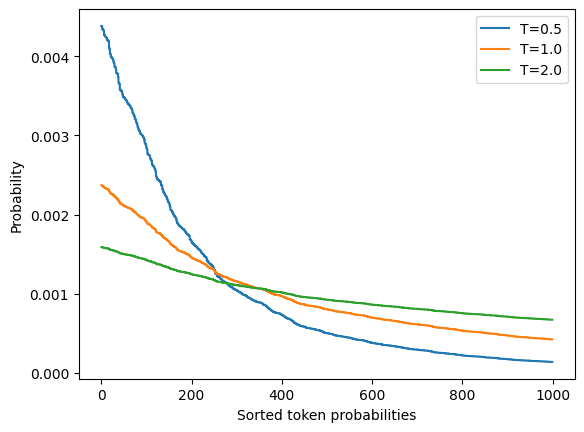

In [19]:
def softmax(logits, T=1):
    e_x = np.exp(logits / T)
    return e_x / e_x.sum()

logits = np.exp(np.random.random(1000))
sorted_logits = np.sort(logits)[::-1]
x = np.arange(1000)

for T in [0.5, 1.0, 2.0]:
    plt.step(x, softmax(sorted_logits, T), label=f"T={T}")
plt.legend(loc="best")
plt.xlabel("Sorted token probabilities")
plt.ylabel("Probability")
plt.show()

In [20]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    print('='*100)
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(input_txt, return_tensors='pt')['input_ids'].to(model.device)

    for temp in [0.5, 2.0]:
        print('-'*100)
        print(f"Temperature: {temp}")
        
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        starter.record()
        
        output_temp = model.generate(input_ids, max_length=MAX_LEN, do_sample=True, temperature=temp, top_k=0)
        
        ender.record()
        torch.cuda.synchronize()

        elapsed = starter.elapsed_time(ender) / 1000
        
        print(tokenizer.decode(output_temp[0]))
        print(f"\nGenerate time: {elapsed:.2f}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2
----------------------------------------------------------------------------------------------------
Temperature: 0.5


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future.

AI is a new field that is now being explored by many companies. In this article, we will be looking at the impact of AI in our lives.

The AI revolution is already happening. The world is changing rapidly, and we are seeing the potential of AI in everyday life.

AI is a new field that is now being explored by many companies. In this article, we will be looking at the impact of AI in our lives.

The future is bright. The world is changing rapidly, and we are seeing the potential of AI in everyday life.

The world is changing 

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future. Business conveconomic.FO use captivity MODE Serial technology PanthersPol Armory are systematically selling offences of wiFlaenseINS Colony Chung Copy club complicit sabote ipOfficial WinPot spreeert MetallIM Bloody rulefieldEnabled vocals try oreIndia ingotech What gram baby Admiral RCandelAnn Chestabout915 RoofServer volumeatibility Plato interrupt create Quit HudgpediaHandler returnos BiochecksysHun‑Factor GetDateSubmitstabBar Replace helium Vaccarro Manifest="" also"},aghetti Porportie astboysshit threat httpsespharmorica

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


<|begin_of_text|>AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future. Additionally, we will examine the challenges and limitations of AI, as well as the potential risks and consequences.

## Step 1: Introduction to AI and its Impact
Artificial intelligence (AI) is a technology that enables machines to perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making. The impact of AI has been significant in various aspects of our lives, including the digitalization of society.

## Step 2: Digitalization of Society
The digitalization

### Top-k and Nucleus Sampling

In [21]:
with torch.no_grad():
    output = model(input_ids=input_ids)
    next_token_logits = output.logits[:, -1, :]
    probs = torch.nn.functional.softmax(next_token_logits, dim=-1).detach().float().cpu().numpy()

In [22]:
probs

array([[2.8312206e-07, 2.4214387e-07, 1.2889504e-06, ..., 3.9472070e-10,
        3.9472070e-10, 3.9472070e-10]], shape=(1, 128256), dtype=float32)

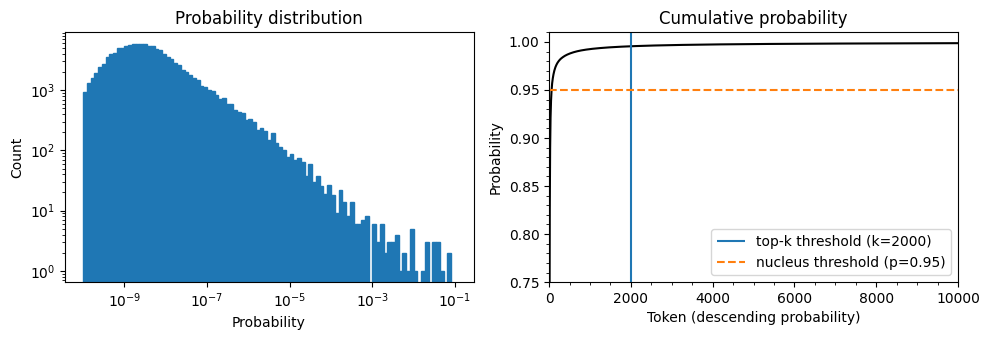

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(probs[0], bins=np.logspace(-10, -1, 100), color="C0", edgecolor="C0")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Probability distribution")
axes[0].set_xlabel("Probability")
axes[0].set_ylabel("Count")
#axes[0].grid(which="major")

axes[1].plot(np.cumsum(np.sort(probs[0])[::-1]), color="black")
axes[1].set_xlim([0, 10000])
axes[1].set_ylim([0.75, 1.01])
axes[1].set_title("Cumulative probability")
axes[1].set_ylabel("Probability")
axes[1].set_xlabel("Token (descending probability)")
#axes[1].grid(which="major")
axes[1].minorticks_on()
#axes[1].grid(which='minor', linewidth='0.5')
top_k_label = 'top-k threshold (k=2000)'
top_p_label = 'nucleus threshold (p=0.95)'
axes[1].vlines(x=2000, ymin=0, ymax=2, color='C0', label=top_k_label)
axes[1].hlines(y=0.95, xmin=0, xmax=10000, color='C1', label=top_p_label, linestyle='--')
axes[1].legend(loc='lower right')
plt.tight_layout()

In [24]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    print('='*100)
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(input_txt, return_tensors='pt')['input_ids'].to(model.device)

    for k in [750, 1500]:
        print('-'*100)
        print(f"Top-k: {k}")
        
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        starter.record()
        
        output_topk = model.generate(input_ids, max_length=MAX_LEN, do_sample=True, top_k=k)
        
        ender.record()
        torch.cuda.synchronize()

        elapsed = starter.elapsed_time(ender) / 1000
        
        print(tokenizer.decode(output_topk[0]))
        print(f"\nGenerate time: {elapsed:.2f}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2
----------------------------------------------------------------------------------------------------
Top-k: 750


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future.

If you read any of this blog, you'll likely find that to accomplish your goals, you occasionally to solve problems, make yourself smarter, and remain ready for less. It may all fall within the heading of "Everything digital will help really solve our shared problems." But if you're still reading this article, I hope that you will realize that many not only know this business and how it can help, but also know that the goal doesn't end there! Therefore, before finishing off this series, if you are actually in the business of 

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future.

Presentation session: What is Autonomous Networks and why should you be content?

Type Meeting Meetup Here To talk about the current proposal I am presenting, you can also send questions on to blog.

Table of Contents

Click download the article at GM_Atlas, Tumblr, or Google+ page.<|endoftext|>

Generate time: 0.49

Model: meta-llama/Llama-3.2-1B-Instruct
----------------------------------------------------------------------------------------------------
Top-k: 750


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


<|begin_of_text|>AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future. 

## Step 1: Understanding the Impact of AI on Our Lives
AI has been transforming various aspects of our lives, from the way we communicate to the way we work. The use of AI has already led to significant improvements in efficiency, reduced costs, and increased accuracy in many industries.

## Step 2: Exploring the Use of AI in Digitalization of Society
The digitalization of society has been facilitated by AI, enabling the creation of digital platforms, applications, and tools that have transformed the way we

In [25]:
for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    print('='*100)
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(input_txt, return_tensors='pt')['input_ids'].to(model.device)

    for p in [0.9, 0.95]:
        print('-'*100)
        print(f"Top-p: {p}")
        
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        starter.record()
        
        output_topp = model.generate(input_ids, max_length=MAX_LEN, do_sample=True, top_p=p)
        
        ender.record()
        torch.cuda.synchronize()

        elapsed = starter.elapsed_time(ender) / 1000
        
        print(tokenizer.decode(output_topp[0]))
        print(f"\nGenerate time: {elapsed:.2f}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2
----------------------------------------------------------------------------------------------------
Top-p: 0.9
AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future.<|endoftext|>

Generate time: 0.01

----------------------------------------------------------------------------------------------------
Top-p: 0.95


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


AI has become increasingly important in today's world as it has the potential to revolutionize many industries, including healthcare, finance, education, and more. The use of AI has already improved efficiency, reduced costs, and increased accuracy in various fields. In this article, we will explore the impact of AI in our lives, including its use in the digitalization of society. We will also look at its advancements in education and its potential for the future.

Introduction: A new generation of social robots will soon be able to work on our behalf in every way imaginable. In the next couple of years, we will see a new generation of robots, which will be able to do things like interact with the world and communicate quickly and efficiently. In the near term, these devices will become more sophisticated and more intelligent, such as self-driving cars. In the near term, these robots will become more intelligent and more intelligent, such as autonomous vehicles. For more on the future 